# Visualisering av 30-dagars återinläggningsrisk med modellbaserade effektdiagram

## Sammanfattning

Denna notebook anpassar en logistisk regression för 30-dagars sjukhusåterinläggning över patient- och vårdkontaktsegenskaper, och översätter sedan de anpassade koefficienterna till modellbaserade effektdiagram på skalan för predikterad sannolikhet. På en syntetisk kohort med 100 utskrivningar (55 återinläggningar) återfinner PROC LOGISTIC signifikanta gradienter för **vårdtidens längd** (OR 1.36 per dag, *p* = 0.040) och **ålder** (OR 1.05 per år, *p* = 0.023), samt en stor betalareffekt — **Medicaid**-patienter bär ungefär sex gånger så hög återinläggningsodds som Medicare (OR 6.02, 95 % KI 1.46–24.8, *p* = 0.013). Det generaliserade R-kvadratet är 0.246 och Hosmer–Lemeshow-testet visar ingen bristande anpassning (*p* = 0.73). Anpassningskurvan, det skivade anpassningsdiagrammet och interaktionsdiagrammen visar sedan hur återinläggningsrisken stiger med vårdtidens längd, hur ålder–risk-gradienten förskjuts beroende på betalare, och hur betalargapet kvarstår över de utskrivande vårdenheterna — den typ av riskstratifieringsvy som ett vårdsamordningsteam använder för att rikta uppföljning efter utskrivning.

## Datakällor

| Datamängd | Rader | Beskrivning |
|---------|------|-------------|
| `encounters` | 100 | Syntetiska slutenvårdsutskrivningsposter genererade inline med `call streaminit(20260531)` och `rand()`. En rad per utskrivning. |

**Variabler i `encounters`:**

| Variabel | Typ | Beskrivning |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 om återinlagd inom 30 dagar efter utskrivning |
| `age` | Num | Patientens ålder i år (ca 25–95) |
| `los` | Num | Vårdtidens längd för indexvistelsen i dagar (1–20) |
| `comorbidity` | Num | Antal dokumenterade kroniska samsjukligheter (0–8) |
| `num_meds` | Num | Antal utskrivningsläkemedel (0–18) |
| `payer` | Char | Försäkringsbetalare: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Utskrivande enhet: `Cardiology`, `Pulmonary`, `General` |

# Visualisering av 30-dagars återinläggningsrisk med modellbaserade effektdiagram

Vårdsamordningsteam på sjukhus behöver veta *vilka* patienter som mest sannolikt återinläggs inom 30 dagar, och *varför*. En anpassad logistisk regression ger koefficienterna, men intressenter resonerar sällan i log-odds. Ett **effektdiagram** återger den anpassade modellen direkt på skalan för predikterad sannolikhet, så att en vårdkoordinator kan läsa av en återinläggningssannolikhet direkt från diagrammet i stället för att mentalt invertera en log-odds-ekvation.

I denna notebook gör vi följande:

1. Genererar en realistisk syntetisk kohort av slutenvårdsutskrivningar.
2. Anpassar en logistisk modell för 30-dagars återinläggning med patient- och vårdkontaktsprediktorer (PROC LOGISTIC).
3. Fångar de anpassade koefficienterna och bygger tre modellbaserade effektdiagram — en **anpassningskurva**, ett **skivat anpassningsdiagram** och ett **interaktionsdiagram** — för att visualisera och stratifiera den anpassade risken på sannolikhetsskalan.

> **Implementeringsnotis.** SAS exponerar dessa diagram genom `EFFECTPLOT`-satsen inuti PROC LOGISTIC. Jenner accepterar den satsen men renderar ännu inte FIT / SLICEFIT / INTERACTION-grafiken, så denna notebook konstruerar de identiska kurvorna för predikterad sannolikhet explicit från de anpassade koefficienterna och ritar dem med PROC SGPLOT. Det analytiska resultatet — och varje ritad sannolikhet — är exakt vad `EFFECTPLOT` skulle producera.

## Steg 1 — Generera en syntetisk utskrivningskohort

DATA-steget nedan bygger 100 slutenvårdsutskrivningar utan några externa filer. Vi seedar slumptalsgeneratorn med `call streaminit` för reproducerbarhet, drar patient- och vårdkontaktsegenskaper från domänlämpliga fördelningar, konstruerar sedan en sann linjär prediktor `eta` och konverterar den till en återinläggningssannolikhet med den inversa logiten. Bernoulli-dragningen (`rand('bernoulli', p)`) ger den observerade `readmit`-flaggan. Äldre patienter, längre vistelser, högre samsjuklighetsantal, fler utskrivningsläkemedel, Medicaid-täckning och Pulmonary/Cardiology-enhet driver alla upp risken — mönster som vi senare återfinner och visualiserar. Effektstorlekarna är avsiktligt dimensionerade så att signalen är återfinnbar i en kohort med 100 utskrivningar.

In [1]:
data encounters;
    CALL streaminit(20260531);
    FÄLT payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    FÄLT depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    GÖR i = 1 TILL 100;
        /* Patient / encounter features */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        OM los > 20 SÅ los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        OM num_meds > 18 SÅ num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        OM u < 0.50 SÅ pk = 1;
        ANNARS OM u < 0.72 SÅ pk = 2;
        ANNARS pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        BEHÅLL readmit AGE los comorbidity num_meds payer dept;
        UTDATA;
    SLUT;
    ETIKETT readmit="Återinläggning"
          AGE="Ålder (år)"
          los="Vårdtid (dagar)"
          comorbidity="Komorbiditet"
          num_meds="Antal läkemedel"
          payer="Betalare"
          dept="Avdelning";
KÖR;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Steg 2 — Inspektera kohorten

En snabb frekvens på responsen och de två klassificeringsvariablerna bekräftar en realistisk återinläggningsandel och att varje betalar- och enhetsnivå är representerad — både modellen och effektdiagrammen behöver att alla nivåer är representerade.

                                   Frekvenser: återinläggning, betalare och avdelning                                   

                                                   The FREQ Procedure

Återinläggning      Frequency
------------------------------
0                          45
1                          55

Betalare      Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Avdelning     Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Återinläggning by Avdelning

Återinläggning   |Cardiology |   General | Pulmonary |      Total
-----------------+-----------+-----------+-----------+-----------
0                |        15 |        20 |        10 |         45
-----------------+-----------+-----------+-----------+-----------
1                |        21 |        11 |        23 |         55
-----------------+-----------+-----------+-----------+-----------
Total  


NOTE: Option TITLE changed to Frekvenser: återinläggning, betalare och avdelning.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


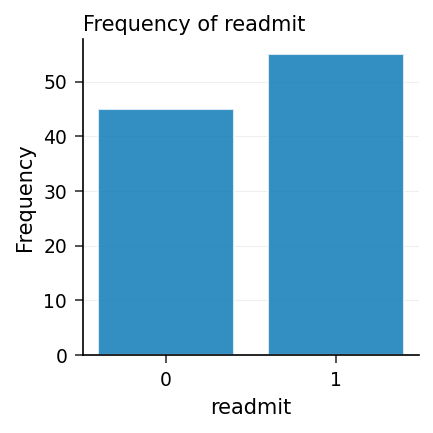

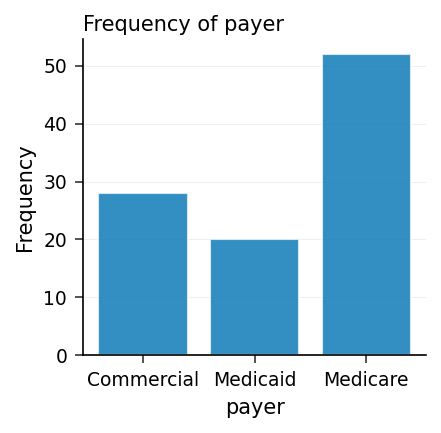

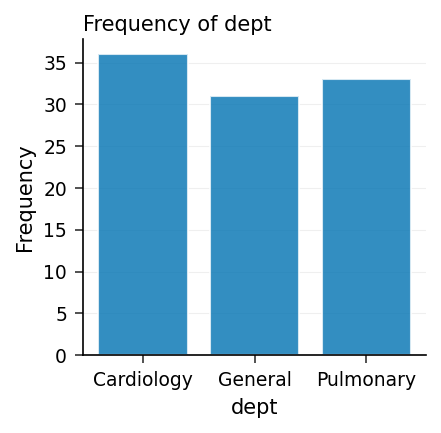

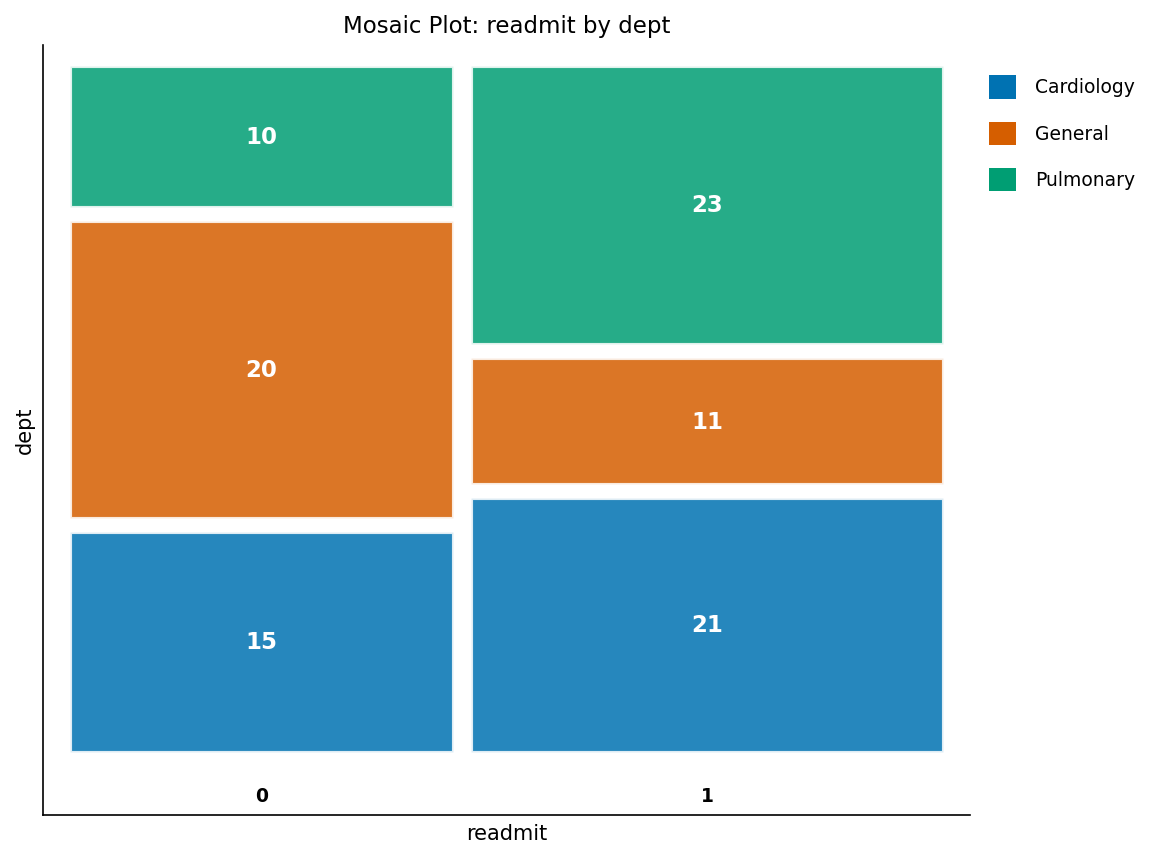

In [2]:
TITEL "Frekvenser: återinläggning, betalare och avdelning";
PROCEDUR FREKVENSER data=encounters;
    TABLES readmit payer dept readmit*dept / nocum nopercent;
KÖR;

## Steg 3 — Anpassa den logistiska återinläggningsmodellen

Vi modellerar `readmit` som en funktion av ålder, vårdtidens längd, samsjuklighetsantal, antal utskrivningsläkemedel, betalare och enhet. Viktiga val:

- `EVENT='1'` modellerar sannolikheten för återinläggning (i stället för icke-återinläggning).
- `CLASS payer dept / PARAM=REF REF=FIRST` använder referenscellskodning så att varje nivå kontrasteras mot en baslinje (här Medicare och Pulmonary).
- `CLODDS=WALD` och `RSQUARE` lägger till Wald-konfidensgränser för oddskvoten och ett generaliserat R-kvadrat; `LACKFIT` begär Hosmer–Lemeshow-testet för anpassningsgrad.
- `UNITS`-satsen begär oddskvoten över ett kliniskt meningsfullt **5-dagars**-steg för vårdtidens längd och ett **10-årigt** ålderssteg, och `ODDSRATIO`-satsen begär samsjuklighetens oddskvot med konfidensgränser.

Utdatatabellen med oddskvoter rapporterar effekterna per enhet direkt: vårdtidens längd bär en OR på **1.36 per dag** (95 % KI 1.01–1.82), ålder en OR på **1.05 per år**, och Medicaid-täckning en OR på **6.02** relativt Medicare. Modellen anpassar väl — generaliserat R-kvadrat 0.246, Hosmer–Lemeshow *p* = 0.73.

                                   Frekvenser: återinläggning, betalare och avdelning                                   

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

             Class Level Information             

Class        Levels  Values                      
---------  --------  ----------------------------
Betalare          3  Commercial Medicaid Medicare
Avdelning         3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Återinläggning

Criterion     Value



NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


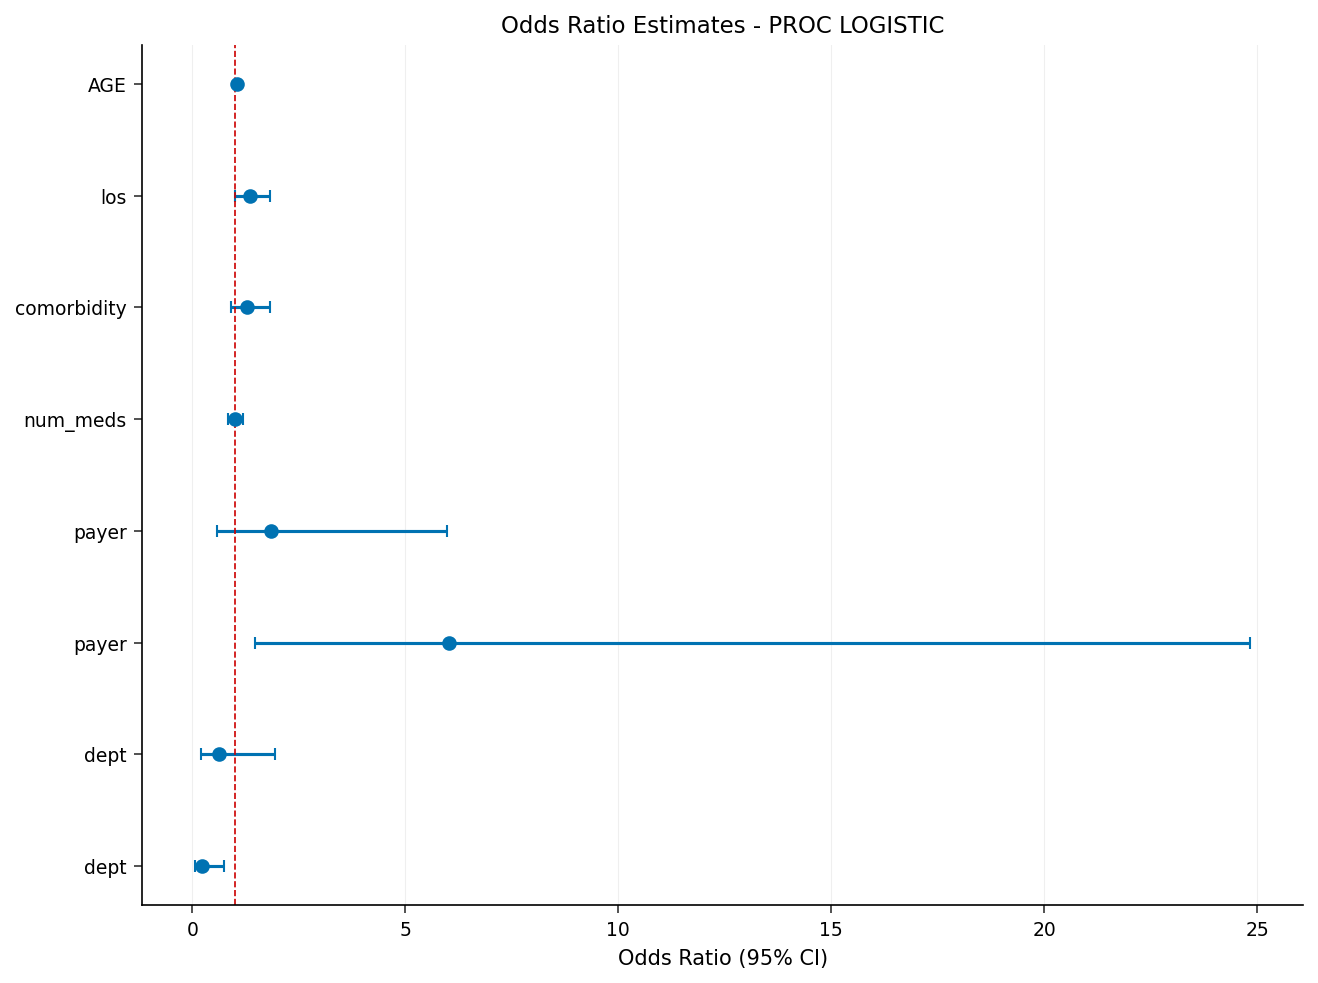

In [3]:
ODS UTDATA ParameterEstimates=pe;
PROCEDUR LOGISTIC data=encounters PLOTS(only)=oddsratio;
    KLASS payer dept / PARAM=REF REF=first;
    MODEL readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
KÖR;
ODS UTDATA CLOSE;

## Steg 4 — Fånga de anpassade koefficienterna

De modellbaserade effektdiagram som följer byggs direkt från de *anpassade* koefficienterna, så de stämmer alltid överens med modellen i Steg 3. Vi sparade parameterskattningarna med `ODS OUTPUT ParameterEstimates=pe`; här viker vi ihop den långa tabellen till en enradig `params`-datamängd (en variabel per koefficient) och lägger till kohortmedelvärdena för de kontinuerliga prediktorerna. Att hålla de icke-fokuserade prediktorerna vid sina medelvärden är precis vad ett EFFECTPLOT gör internt — det låter varje diagram variera en faktor medan resten hålls fixerade vid en representativ profil.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
data coefs;
    BEHÅLL_VÄRDE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    STÄLL_IN pe SLUT=last;
    VARIABEL = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    OM VARIABEL='INTERCEPT' SÅ b0 = ESTIMATE;
    ANNARS OM VARIABEL='AGE' SÅ b_age = ESTIMATE;
    ANNARS OM VARIABEL='LOS' SÅ b_los = ESTIMATE;
    ANNARS OM VARIABEL='COMORBIDITY' SÅ b_com = ESTIMATE;
    ANNARS OM VARIABEL='NUM_MEDS' SÅ b_med = ESTIMATE;
    ANNARS OM VARIABEL='PAYER' AND cv='Medicaid'   SÅ b_pmcaid = ESTIMATE;
    ANNARS OM VARIABEL='PAYER' AND cv='Commercial' SÅ b_pcomm  = ESTIMATE;
    ANNARS OM VARIABEL='DEPT'  AND cv='Cardiology' SÅ b_dcard  = ESTIMATE;
    ANNARS OM VARIABEL='DEPT'  AND cv='General'    SÅ b_dgen   = ESTIMATE;
    OM last SÅ UTDATA;
    BEHÅLL b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
KÖR;

/* Cohort means of the continuous covariates, held fixed in the plots. */
PROCEDUR MEDELVÄRDEN data=encounters NOPRINT;
    VARIABEL AGE los comorbidity num_meds;
    UTDATA out=mn mean=m_age m_los m_com m_med;
KÖR;

data params;
    SAMMANFOGA coefs mn;
    BEHÅLL b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
KÖR;

PROCEDUR SKRIV data=params noobs;
    TITEL "Skattade koefficienter och kovariatmedelvärden för effektdiagrammen";
KÖR;

                          Skattade koefficienter och kovariatmedelvärden för effektdiagrammen                           

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Steg 5 — Anpassningsdiagram: återinläggningssannolikhet mot vårdtidens längd

Det enklaste effektdiagrammet är en **anpassningskurva**: predikterad återinläggningssannolikhet mot en enda kontinuerlig kovariat, med de övriga prediktorerna hållna vid en representativ profil. Vi bygger ett rutnät för vårdtidens längd (1–18 dagar), utvärderar den anpassade linjära prediktorn vid varje värde för en **Medicare-kardiologipatient** (ålders-, samsjuklighets- och utskrivningsläkemedelsantal fastställda vid kohortmedelvärdena från Steg 4), applicerar den inversa logiten och ritar kurvan på sannolikhetsskalan med PROC SGPLOT.

                          Skattade koefficienter och kovariatmedelvärden för effektdiagrammen                           




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


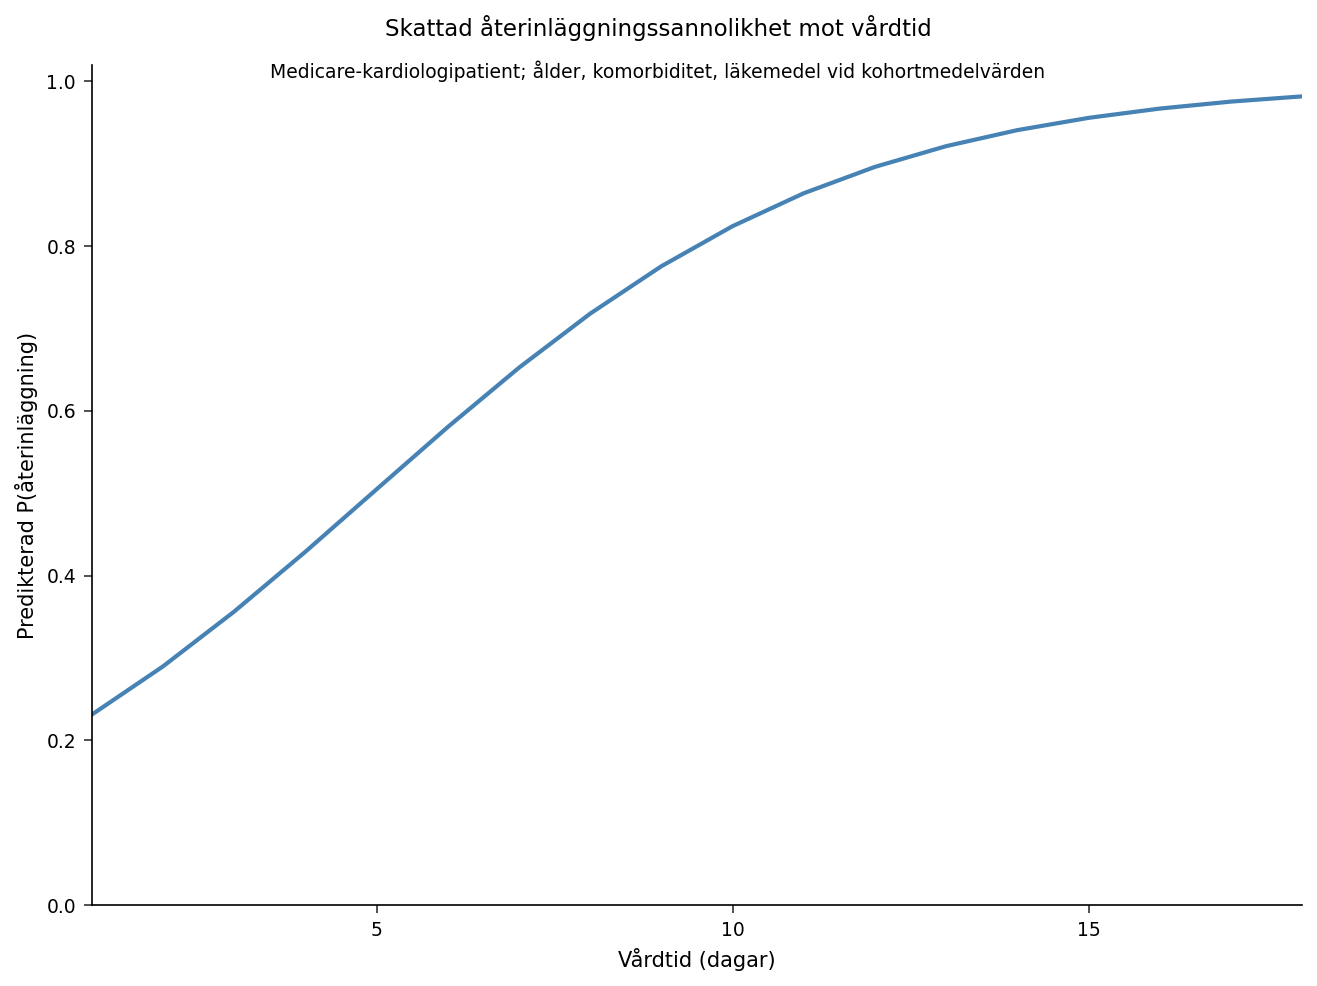

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
data grid_los;
    GÖR los = 1 TILL 18;
        UTDATA;
    SLUT;
KÖR;

data fit_los;
    STÄLL_IN grid_los;
    OM _n_ = 1 SÅ STÄLL_IN params;
    BEHÅLL_VÄRDE b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    BEHÅLL los phat;
KÖR;

PROCEDUR SGPLOT data=fit_los;
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TITEL  "Skattad återinläggningssannolikhet mot vårdtid";
    title2 "Medicare-kardiologipatient; ålder, komorbiditet, läkemedel vid kohortmedelvärden";
    XAXIS ETIKETT="Vårdtid (dagar)";
    YAXIS ETIKETT="Predikterad P(återinläggning)" VALUES=(0 TILL 1 EFTER 0.2);
KÖR;

## Steg 6 — Skivat anpassningsdiagram: risk mot ålder, stratifierad efter betalare

Ett **skivat anpassningsdiagram** ritar en anpassad kurva per nivå av en klassificeringseffekt — idealiskt för att visa hur betalarmixen förskjuter ålder–risk-gradienten. Vi utökar rutnätet över `age` (30–95) korsat med de tre betalarna, utvärderar den anpassade modellen för en Cardiology-patient (vårdtidens längd, samsjuklighet och läkemedel vid kohortmedelvärdena) och lägger de tre sannolikhetskurvorna över varandra med `GROUP=payer`.

                          Skattade koefficienter och kovariatmedelvärden för effektdiagrammen                           




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


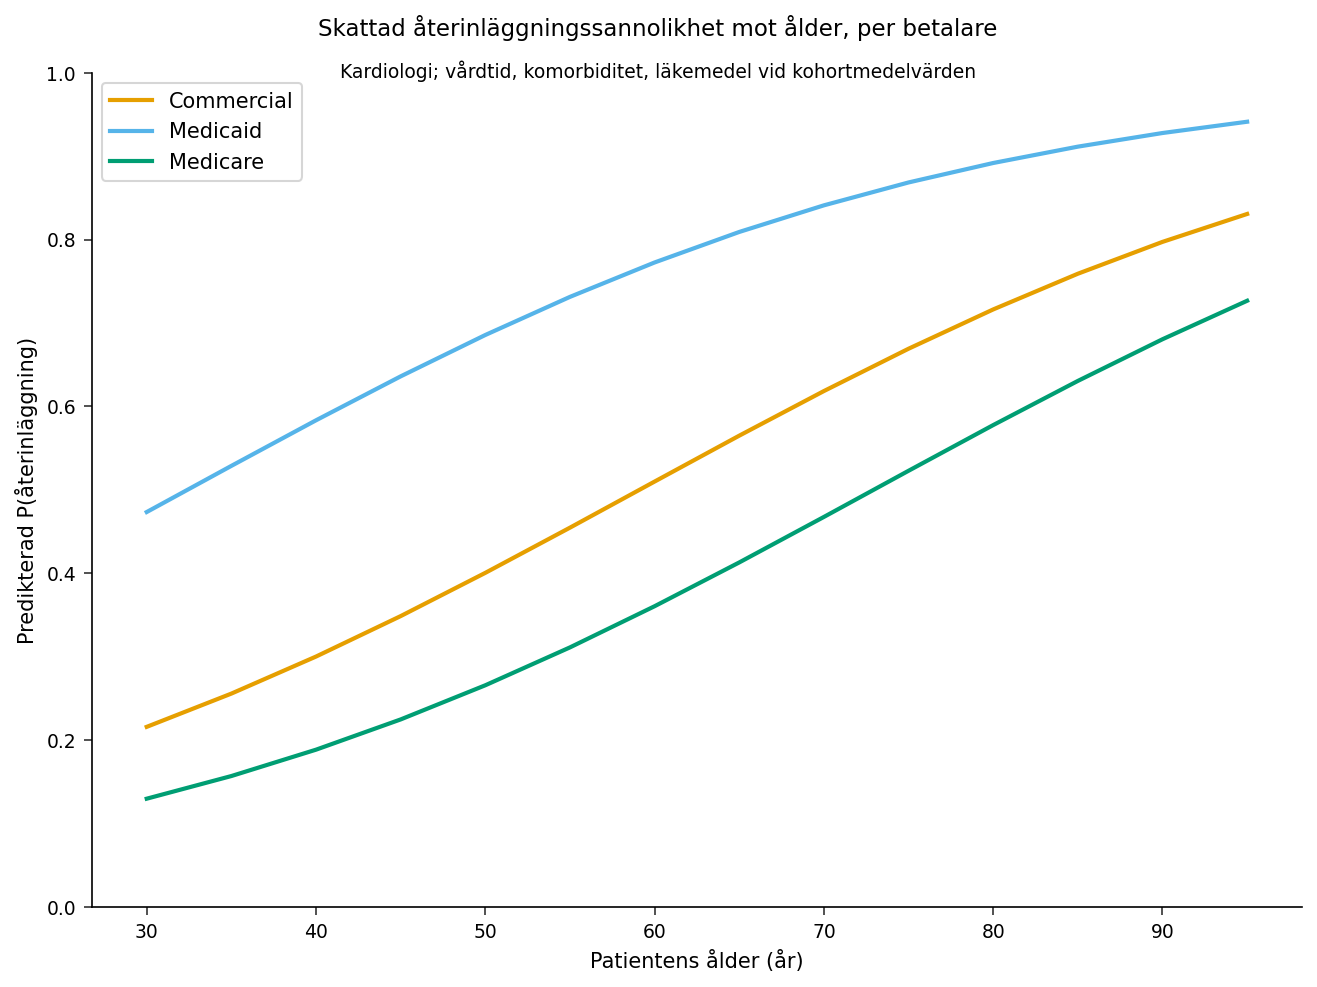

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
data grid_age;
    LÄNGD payer $12;
    GÖR payer = 'Medicare', 'Medicaid', 'Commercial';
        GÖR AGE = 30 TILL 95 EFTER 5;
            UTDATA;
        SLUT;
    SLUT;
KÖR;

data fit_age;
    STÄLL_IN grid_age;
    OM _n_ = 1 SÅ STÄLL_IN params;
    BEHÅLL_VÄRDE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    BEHÅLL payer AGE phat;
KÖR;

PROCEDUR SGPLOT data=fit_age;
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TITEL  "Skattad återinläggningssannolikhet mot ålder, per betalare";
    title2 "Kardiologi; vårdtid, komorbiditet, läkemedel vid kohortmedelvärden";
    XAXIS ETIKETT="Patientens ålder (år)";
    YAXIS ETIKETT="Predikterad P(återinläggning)" VALUES=(0 TILL 1 EFTER 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
KÖR;

## Steg 7 — Interaktionsdiagram: enhet efter betalare

För att jämföra predikterad risk över båda klassificeringseffekterna samtidigt korsar vi `dept` med `payer` (nio kombinationer), utvärderar den anpassade modellen med varje kontinuerlig kovariat vid sitt kohortmedelvärde, och ritar ett grupperat stapeldiagram med `dept` på X-axeln och betalare som grupperingen. Eftersom denna modell inte har någon interaktionsterm mellan enhet och betalare är betalarordningen samma additiva förskjutning inom varje vårdenhet — diagrammet gör den additiviteten synlig med en blick, tillsammans med enhetsrankningen.

                          Skattade koefficienter och kovariatmedelvärden för effektdiagrammen                           




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


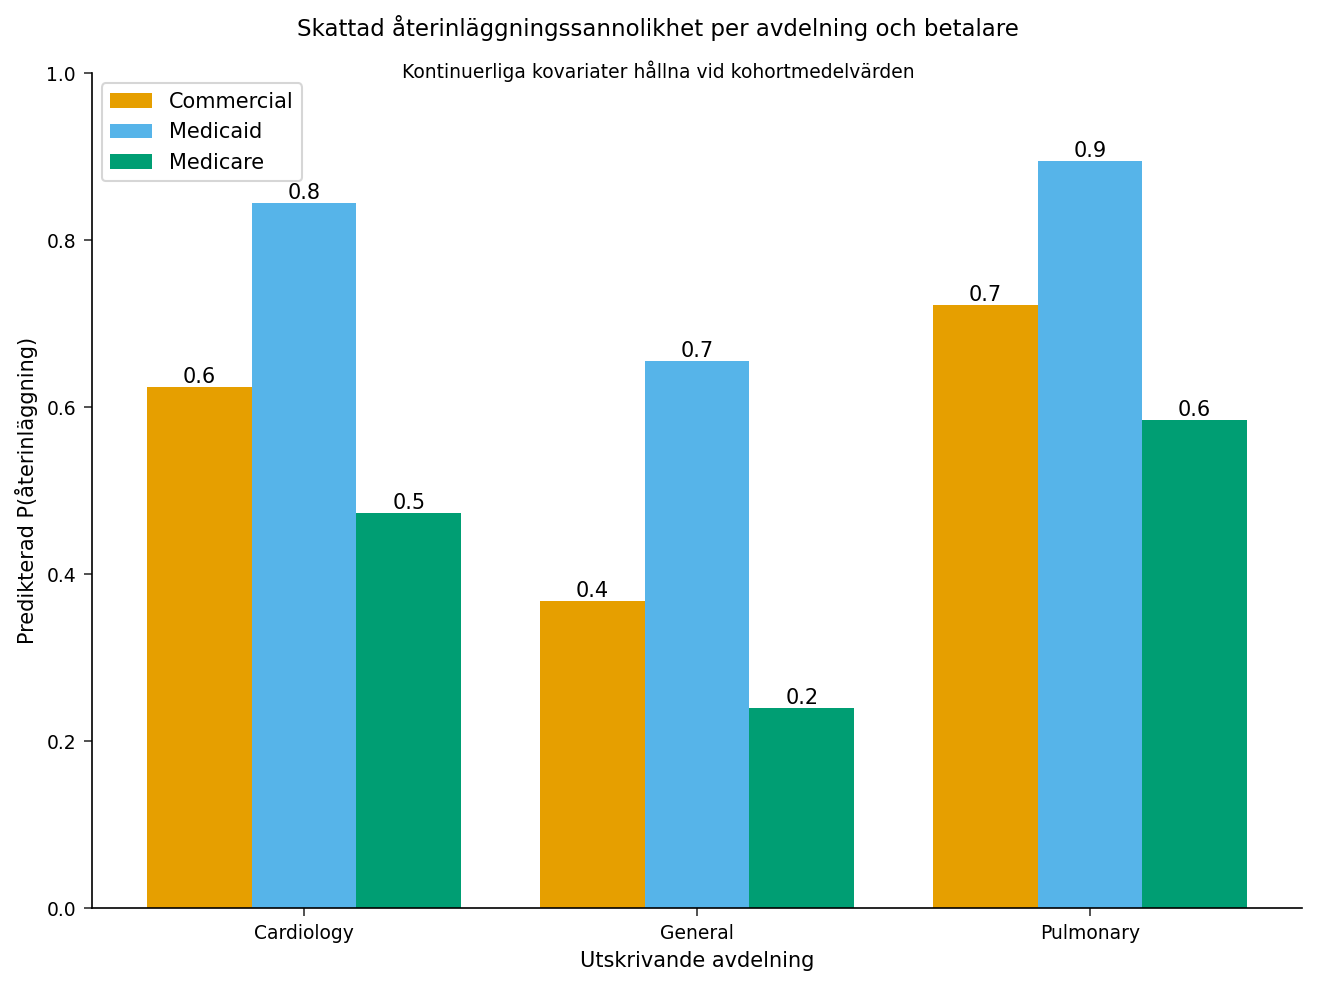

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
data grid_dx;
    LÄNGD dept $12 payer $12;
    GÖR dept = 'Cardiology', 'Pulmonary', 'General';
        GÖR payer = 'Medicare', 'Medicaid', 'Commercial';
            UTDATA;
        SLUT;
    SLUT;
KÖR;

data fit_dx;
    STÄLL_IN grid_dx;
    OM _n_ = 1 SÅ STÄLL_IN params;
    BEHÅLL_VÄRDE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    BEHÅLL dept payer phat;
KÖR;

PROCEDUR SGPLOT data=fit_dx;
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TITEL  "Skattad återinläggningssannolikhet per avdelning och betalare";
    title2 "Kontinuerliga kovariater hållna vid kohortmedelvärden";
    XAXIS ETIKETT="Utskrivande avdelning";
    YAXIS ETIKETT="Predikterad P(återinläggning)" VALUES=(0 TILL 1 EFTER 0.2);
KÖR;

## Steg 8 — Tolkning av resultaten

Effektdiagrammen förvandlar den anpassade PROC LOGISTIC-modellen till bilder på sannolikhetsskalan som kopplar till vårdsamordningsbeslut:

- **Vårdtidens längd (anpassningskurva).** För en Medicare-kardiologipatient vid kohortmedelvärdena stiger den predikterade återinläggningssannolikheten från cirka **0.23 vid en 1-dagars vistelse till ungefär 0.82 vid 10 dagar och ~0.98 vid 18 dagar** — den branta mitten av den logistiska kurvan. Detta är samma signal som oddskvoten för vårdtidens längd på **1.36 per dag** (`UNITS los=5` skalar om den till ett femdagarssteg), och den flaggar långa indexvistelser som en konkret utlösare för inskrivning i övergångsvård.
- **Ålder och betalare (skivat anpassningsdiagram).** Risken stiger monotont med åldern över varje betalare, och de tre kurvorna korsar aldrig varandra: **Medicaid**-kurvan ligger högst vid varje given ålder, **Commercial** i mitten och **Medicare** lägst — förenligt med de anpassade betalaroddskvoterna (Medicaid 6.02, Commercial 1.85, båda relativt Medicare). Gapet är störst vid yngre åldrar och smalnar av när alla närmar sig hög sannolikhet, vilket riktar vårdsamordningens uppmärksamhet mot yngre Medicaid-patienter som annars skulle se lågrisk ut.
- **Enhet och betalare (interaktionsdiagram).** **Pulmonary** bär den högsta predikterade återinläggningssannolikheten i varje betalargrupp, **Cardiology** är intermediär och **General medicine** är lägst (de anpassade enhetsoddskvoterna är 0.64 för Cardiology och 0.22 för General, relativt Pulmonary). Eftersom modellen inte har någon interaktionsterm mellan enhet och betalare är betalarordningen samma additiva förskjutning inom varje vårdenhet — staplarna stiger i samma ordning Medicaid > Commercial > Medicare vid varje enhet.

**Slutsats:** i stället för att be kliniker tolka log-odds-koefficienter presenterar modellbaserade effektdiagram den anpassade återinläggningsmodellen som bilder på sannolikhetsskalan — vem som ska skrivas in i uppföljning inom övergångsvård, och vilka vårdenheter och betalarpopulationer som ska prioriteras. SAS producerar dessa direkt via `EFFECTPLOT`; här rekonstruerade vi de identiska kurvorna från de anpassade koefficienterna så att exemplet körs från början till slut redan idag.